# Leakage-Safe Forecasting Baselines
This notebook evaluates three predeclared baselines for 70 department-store daily sales series over six expanding-window development folds. It never reads the M5 evaluation file or `d_1914`–`d_1941`. No learned model or final feature pipeline is created.

## Task, temporal validation, and leakage controls
The target is each store-department's next 28 daily unit-sales values. Every fold trains on `d_1` through its cutoff and validates on the following 28 days. RMSSE scaling and all baseline inputs use that fold's training slice only. Seasonal naïve repeats `T-6...T`; it never consumes validation actuals. The final lockbox is outside the file loaded below.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from marketmind.forecasting.metrics import rmsse, mae, wape, forecast_bias
DATA = ROOT / 'data/raw/m5/sales_train_validation.csv'
DAYS = [f'd_{i}' for i in range(1, 1914)]
FOLDS = [(1,1465,1466,1493),(2,1549,1550,1577),(3,1633,1634,1661),(4,1717,1718,1745),(5,1801,1802,1829),(6,1885,1886,1913)]
assert len(FOLDS) == 6 and all(e-s+1 == 28 for _,_,s,e in FOLDS) and max(e for *_,e in FOLDS) == 1913

Matplotlib is building the font cache; this may take a moment.


## Build the core series and freeze demonstration selection
Item-store selection uses only descriptive statistics over `d_1`–`d_1913` and occurs before any item baseline is evaluated. Eligible series have at least 730 days from first to last positive sale and at least 100 units. Within each zero-share regime, the three closest to its median are selected, with stable-ID tie-breaking.

In [2]:
raw = pd.read_csv(DATA, usecols=['id','dept_id','store_id','state_id', *DAYS])
core = raw.groupby(['state_id','store_id','dept_id'], sort=True, observed=True)[DAYS].sum().reset_index()
assert len(core) == 70 and core[['store_id','dept_id']].drop_duplicates().shape[0] == 70
y_item = raw[DAYS].to_numpy()
active = y_item > 0
selection = raw[['id','state_id','store_id','dept_id']].copy()
selection['zero_share'] = 1 - active.mean(axis=1)
selection['history_length'] = y_item.shape[1] - active[:, ::-1].argmax(axis=1) - active.argmax(axis=1)
selection['total_sales'] = y_item.sum(axis=1)
eligible = (selection.history_length >= 730) & (selection.total_sales >= 100)
regimes = {'dense': selection.zero_share < .25, 'moderate': selection.zero_share.between(.25,.75,inclusive='left'), 'high': selection.zero_share >= .75}
chosen = []
for regime, mask in regimes.items():
    candidates = selection[eligible & mask].copy()
    median = candidates.zero_share.median()
    candidates['distance_to_median'] = (candidates.zero_share - median).abs()
    selected = candidates.sort_values(['distance_to_median','id'], kind='mergesort').head(3).copy()
    selected['regime'] = regime
    selected['regime_median'] = median
    chosen.append(selected)
chosen = pd.concat(chosen, ignore_index=True)
assert len(chosen) == 9 and chosen.id.nunique() == 9
chosen[['regime','id','zero_share','history_length','total_sales']]

/var/folders/qr/5t89y2n92z12ddb73k2_ybdm0000gn/T/ipykernel_60880/1688141770.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  core = raw.groupby(['state_id','store_id','dept_id'], sort=True, observed=True)[DAYS].sum().reset_index()


,regime,id,zero_share,history_length,total_sales
0,dense,FOODS_3_116_CA_3_validation,0.165708,1913,12466
1,dense,FOODS_3_295_WI_1_validation,0.165708,1913,18231
2,dense,FOODS_3_394_CA_3_validation,0.165708,1912,4745
3,moderate,FOODS_1_118_WI_1_validation,0.569263,1377,1784
4,moderate,FOODS_1_127_TX_3_validation,0.569263,1913,1596
5,moderate,FOODS_1_185_WI_3_validation,0.569263,1904,1600
6,high,FOODS_1_125_TX_3_validation,0.852065,899,468
7,high,FOODS_1_189_TX_2_validation,0.852065,1514,378
8,high,FOODS_2_111_TX_3_validation,0.852065,1200,446


## Baselines and metrics
Last-value repeats `y_T`; seasonal naïve repeats the final seven training values four times; historical mean repeats the mean of the final 28 training days. RMSSE uses only one-step changes inside the current fold's training slice. WAPE and relative bias are undefined when actual totals are non-positive; positive bias means overforecasting.

In [3]:
def forecasts(train):
    return {
        'last_value': np.repeat(train[:, -1, None], 28, axis=1),
        'seasonal_naive_7': np.tile(train[:, -7:], (1, 4)),
        'historical_mean_28': np.repeat(train[:, -28:].mean(axis=1)[:, None], 28, axis=1),
    }
def evaluate(frame, id_columns):
    values = frame[DAYS].to_numpy(dtype=float)
    rows = []
    for fold, train_end, val_start, val_end in FOLDS:
        train, actual = values[:, :train_end], values[:, val_start-1:val_end]
        for baseline, prediction in forecasts(train).items():
            for i in range(len(frame)):
                rows.append({**{c: frame.iloc[i][c] for c in id_columns}, 'fold':fold, 'baseline':baseline,
                    'rmsse':rmsse(actual[i],prediction[i],train[i]), 'mae':mae(actual[i],prediction[i]),
                    'absolute_error':np.abs(actual[i]-prediction[i]).sum(), 'actual_total':actual[i].sum(),
                    'signed_error':(prediction[i]-actual[i]).sum()})
    result = pd.DataFrame(rows)
    result['wape'] = result.absolute_error / result.actual_total.replace(0,np.nan)
    result['bias'] = result.signed_error / result.actual_total.replace(0,np.nan)
    return result
core_results = evaluate(core, ['state_id','store_id','dept_id'])
assert len(core_results) == 70*6*3 and core_results.rmsse.notna().all()
core_results.head()

,state_id,store_id,dept_id,fold,baseline,rmsse,mae,absolute_error,actual_total,signed_error,wape,bias
0,CA,CA_1,FOODS_1,1,last_value,1.462376,81.357143,2278.0,10548.0,-804.0,0.215965,-0.076223
1,CA,CA_1,FOODS_2,1,last_value,1.441365,139.071429,3894.0,12974.0,2566.0,0.300139,0.197780
2,CA,CA_1,FOODS_3,1,last_value,1.936084,849.000000,23772.0,55468.0,23156.0,0.428571,0.417466
3,CA,CA_1,HOBBIES_1,1,last_value,1.038907,112.607143,3153.0,13535.0,1809.0,0.232952,0.133653
4,CA,CA_1,HOBBIES_2,1,last_value,2.558048,32.892857,921.0,1067.0,921.0,0.863168,0.863168


In [4]:
overall = core_results.groupby('baseline').agg(macro_rmsse=('rmsse','mean'), median_rmsse=('rmsse','median'), rmsse_q25=('rmsse',lambda x:x.quantile(.25)), rmsse_q75=('rmsse',lambda x:x.quantile(.75)), macro_mae=('mae','mean'), absolute_error=('absolute_error','sum'), actual_total=('actual_total','sum'), signed_error=('signed_error','sum')).reset_index()
overall['pooled_wape'] = overall.absolute_error / overall.actual_total
overall['pooled_bias'] = overall.signed_error / overall.actual_total
overall.drop(columns=['absolute_error','actual_total','signed_error']).sort_values('macro_rmsse')

,baseline,macro_rmsse,median_rmsse,rmsse_q25,rmsse_q75,macro_mae,pooled_wape,pooled_bias
0,historical_mean_28,1.066903,0.985350,0.835917,1.196182,99.422145,0.178333,-0.018127
2,seasonal_naive_7,1.069671,0.965833,0.764507,1.262156,91.484864,0.164096,-0.010948
1,last_value,1.532226,1.382918,1.047781,1.807050,162.153231,0.290854,0.161543


In [5]:
fold_results = core_results.groupby(['fold','baseline']).agg(macro_rmsse=('rmsse','mean'), median_rmsse=('rmsse','median'), q25=('rmsse',lambda x:x.quantile(.25)), q75=('rmsse',lambda x:x.quantile(.75)), macro_mae=('mae','mean'), absolute_error=('absolute_error','sum'), actual_total=('actual_total','sum'), signed_error=('signed_error','sum')).reset_index()
fold_results['pooled_wape'] = fold_results.absolute_error / fold_results.actual_total
fold_results['pooled_bias'] = fold_results.signed_error / fold_results.actual_total
fold_results.drop(columns=['absolute_error','actual_total','signed_error'])

,fold,baseline,macro_rmsse,median_rmsse,q25,q75,macro_mae,pooled_wape,pooled_bias
0,1,historical_mean_28,1.134867,1.054406,0.864056,1.316736,100.686188,0.190363,-0.057872
1,1,last_value,1.805146,1.620077,1.306529,2.352466,194.695918,0.368103,0.090773
2,1,seasonal_naive_7,1.215038,1.099392,0.922587,1.465222,103.727551,0.196113,-0.061568
3,2,historical_mean_28,0.914865,0.884830,0.779560,1.070850,85.892201,0.163589,0.004642
4,2,last_value,1.329799,1.204902,0.972849,1.527358,133.871939,0.254971,0.181009
5,2,seasonal_naive_7,0.928540,0.876858,0.663329,1.091143,71.967857,0.137069,-0.044549
6,3,historical_mean_28,0.945059,0.885065,0.757818,1.037298,91.600765,0.159157,-0.015099
7,3,last_value,1.328186,1.212666,0.916229,1.644641,143.384694,0.249132,0.186071
8,3,seasonal_naive_7,0.862696,0.817675,0.661173,0.982186,72.851020,0.126579,0.016806
9,4,historical_mean_28,1.178949,1.005144,0.858571,1.292902,101.626895,0.183537,0.043091


## Error characterization and analytical plots
The plots compare fold stability, per-series RMSSE dispersion, department patterns, and one representative validation example. These are analytical diagnostics, not dashboard visuals.

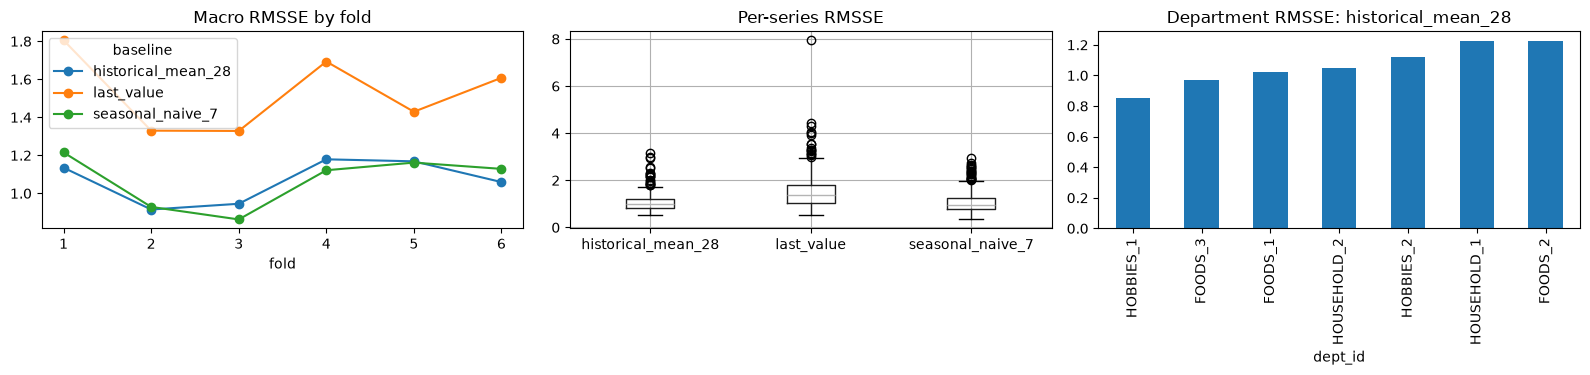

(baseline                     historical_mean_28  last_value  seasonal_naive_7  \
 state_id store_id dept_id                                                       
 TX       TX_2     HOBBIES_1            0.758010    0.928683          0.794247   
                   FOODS_2              0.772681    1.004290          0.732055   
          TX_1     FOODS_3              0.778626    1.795930          0.730098   
          TX_2     FOODS_3              0.784144    1.479663          0.602633   
                   FOODS_1              0.785566    1.448180          1.105136   
 WI       WI_2     HOBBIES_1            0.786288    1.234116          0.994872   
 CA       CA_1     HOBBIES_1            0.789970    1.059053          0.817940   
 TX       TX_1     FOODS_2              0.810221    1.571745          0.889013   
 CA       CA_2     HOBBIES_1            0.846103    1.183771          0.740347   
 WI       WI_3     HOBBIES_1            0.853727    1.205179          0.936133   
 
 baseline     

In [6]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
fold_results.pivot(index='fold',columns='baseline',values='macro_rmsse').plot(marker='o',ax=axes[0],title='Macro RMSSE by fold')
core_results.boxplot(column='rmsse',by='baseline',ax=axes[1]); axes[1].set_title('Per-series RMSSE'); axes[1].set_xlabel(''); plt.suptitle('')
strongest = overall.sort_values('macro_rmsse').iloc[0].baseline
core_results[core_results.baseline==strongest].groupby('dept_id').rmsse.mean().sort_values().plot.bar(ax=axes[2],title=f'Department RMSSE: {strongest}')
plt.tight_layout(); plt.show()
series_summary = core_results.groupby(['state_id','store_id','dept_id','baseline']).rmsse.mean().unstack('baseline')
series_summary['seasonal_gain_vs_last'] = series_summary.last_value-series_summary.seasonal_naive_7
series_summary['mean_gain_vs_best_other'] = np.minimum(series_summary.last_value,series_summary.seasonal_naive_7)-series_summary.historical_mean_28
series_summary.sort_values(strongest).head(10), series_summary.sort_values(strongest).tail(10)

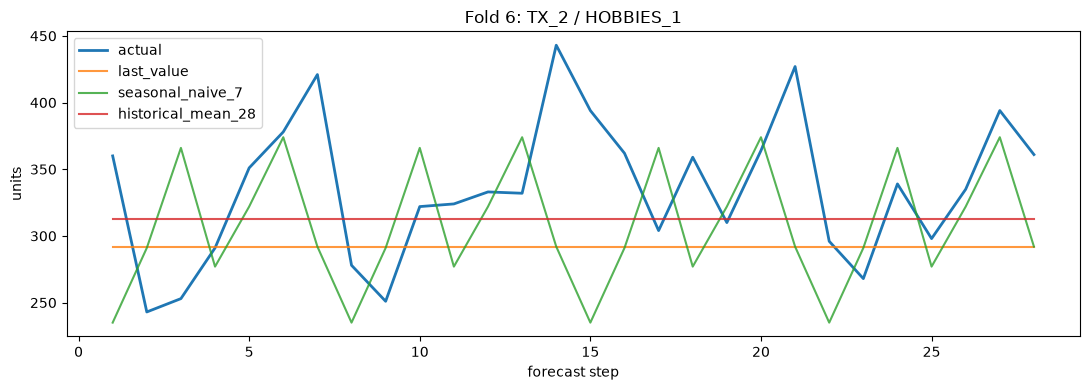

In [7]:
example = core[(core.store_id=='TX_2') & (core.dept_id=='HOBBIES_1')].iloc[0]
values = example[DAYS].to_numpy(float); _,train_end,val_start,val_end = FOLDS[-1]
train = values[:train_end][None,:]; actual = values[val_start-1:val_end]
plt.figure(figsize=(11,4)); plt.plot(range(1,29),actual,label='actual',linewidth=2)
for name,pred in forecasts(train).items(): plt.plot(range(1,29),pred[0],label=name,alpha=.8)
plt.title('Fold 6: TX_2 / HOBBIES_1'); plt.xlabel('forecast step'); plt.ylabel('units'); plt.legend(); plt.tight_layout(); plt.show()

## Secondary intermittent-demand demonstration
The same baselines are evaluated descriptively for the nine preselected item-store series. These results cannot change the core grain, selection, or benchmark. Increasing intermittency makes percentage-normalized absolute error especially unstable and often greater than 100%, even when unit MAE is small.

In [8]:
item_demo = raw[raw.id.isin(chosen.id)].merge(chosen[['id','regime']],on='id').sort_values(['regime','id'])
item_results = evaluate(item_demo, ['id','regime'])
item_summary = item_results.groupby(['regime','baseline']).agg(macro_rmsse=('rmsse','mean'), macro_mae=('mae','mean'), absolute_error=('absolute_error','sum'), actual_total=('actual_total','sum'), signed_error=('signed_error','sum'), invalid_rmsse=('rmsse',lambda x:x.isna().sum())).reset_index()
item_summary['pooled_wape'] = item_summary.absolute_error/item_summary.actual_total
item_summary['pooled_bias'] = item_summary.signed_error/item_summary.actual_total
item_summary.drop(columns=['absolute_error','actual_total','signed_error'])

,regime,baseline,macro_rmsse,macro_mae,invalid_rmsse,pooled_wape,pooled_bias
0,dense,historical_mean_28,0.754377,3.807115,0,0.750405,0.067657
1,dense,last_value,0.893017,3.946429,0,0.777865,-0.277278
2,dense,seasonal_naive_7,0.950024,4.267857,0,0.841220,-0.050450
3,high,historical_mean_28,0.857765,0.534014,0,1.447005,0.177419
4,high,last_value,0.966390,0.523810,0,1.419355,-0.247312
5,high,seasonal_naive_7,1.078366,0.551587,0,1.494624,0.268817
6,moderate,historical_mean_28,0.713251,0.951531,0,1.001193,0.056367
7,moderate,last_value,0.926718,1.200397,0,1.263048,-0.064718
8,moderate,seasonal_naive_7,0.954251,1.164683,0,1.225470,0.052192


## Interpretation
The 28-day historical mean is the benchmark under the frozen primary macro RMSSE, but its overall lead over seasonal naïve is small and fold leadership is split. Seasonal naïve has lower unit MAE and pooled WAPE. Last value is clearly weaker. Future learned models must be compared with all three, using the same folds and full per-series reporting. No lockbox result appears here.